# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


In [4]:
# información general
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
#Correccion de formato de dato para la columna 'date'
df['date'] = pd.to_datetime(df['date'])

In [6]:
#Revision si hay datos nulos 
df.isna().sum()

user_id           0
date              0
landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
converted         0
gasto             0
dtype: int64

In [7]:
#revision si hay filas duplicadas
df.duplicated().sum()

0

In [8]:
#revision de los valores numericos de la columna 'gasto'
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# revisar posibles outliers in columna 'gasto'
df[df['gasto']>100].sort_values(by ='gasto',ascending=False)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
35068,029502f6-56c2-4e82-8e22-d7d2f3dd8515,2026-01-10,A,Sur,Desktop,Email,Nuevo,1,303.68
15189,2a4da7a1-d0db-41c7-b9ab-efd4c4748e0c,2026-01-02,A,Oriente,Desktop,Ads,Recurrente,1,269.91
10822,1ea885eb-8650-4c22-8cd2-e3718d4082af,2026-01-09,B,Centro,Mobile,Organic,Recurrente,1,249.99
1185,8771dabd-5b60-468e-915a-60ef6c0ebb66,2026-01-12,B,Norte,Desktop,Organic,Nuevo,1,244.89
22823,0035c847-2e8b-4499-be6c-b4c624f58e56,2026-01-10,B,Norte,Desktop,Ads,Nuevo,1,231.37
...,...,...,...,...,...,...,...,...,...
39313,e36bdb92-b9d0-412c-b430-5ddb11d29e90,2026-01-23,A,Sur,Desktop,Organic,Recurrente,1,100.17
14056,dac4e64b-e1e9-45f0-8071-2bfdb6fe2962,2026-01-27,B,Occidente,Desktop,Ads,Recurrente,1,100.15
711,cd5af5bf-692a-4058-b0a6-b5510934d311,2026-01-19,A,Norte,Mobile,Ads,Nuevo,1,100.12
34862,723e7e22-3316-44f5-b33b-04054de29b24,2026-01-18,B,Norte,Desktop,Ads,Recurrente,1,100.08


In [10]:
resultado = df[df['gasto']>100].sort_values(by='gasto', ascending=False)

In [11]:
resultado.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
35068,029502f6-56c2-4e82-8e22-d7d2f3dd8515,2026-01-10,A,Sur,Desktop,Email,Nuevo,1,303.68
15189,2a4da7a1-d0db-41c7-b9ab-efd4c4748e0c,2026-01-02,A,Oriente,Desktop,Ads,Recurrente,1,269.91
10822,1ea885eb-8650-4c22-8cd2-e3718d4082af,2026-01-09,B,Centro,Mobile,Organic,Recurrente,1,249.99
1185,8771dabd-5b60-468e-915a-60ef6c0ebb66,2026-01-12,B,Norte,Desktop,Organic,Nuevo,1,244.89
22823,0035c847-2e8b-4499-be6c-b4c624f58e56,2026-01-10,B,Norte,Desktop,Ads,Nuevo,1,231.37


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves
- Se observa que la columna 'date' no tiene el formato correcto, ya que deberia ser 'datetime'.Convertimos la columna 'date' a formato 'datetime' para poder trabajar con las fechas correctas.
 -Se han revisado tambien los valores minimos y maximos de la columna de variables numericas 'gasto' y se ha encontrado que el valor maximo es mayor con $33 lo que es un salto parecido a los siguiente gastos mas altos.   


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [12]:
#Revision de usuarios unicos 
df['user_id'].nunique()


40000

In [13]:
#Revision de usuarios unicos 
df.shape[0]

40000

 **Variable `date`**  
Explorar rango de fechas

In [14]:
# Resumen estadístico
df["date"].describe()

count                   40000
unique                     28
top       2026-01-24 00:00:00
freq                     1512
first     2026-01-01 00:00:00
last      2026-01-28 00:00:00
Name: date, dtype: object

In [15]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [16]:
# Resumen estadístico
print(df['gasto'].describe())

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64


In [17]:
df[df['converted']==1].shape

(5706, 9)

In [18]:
df[df['gasto']>0].shape

(5706, 9)

In [19]:
#Filtro por los usuarios convertidos para revision de resumen estadistico
usuarios_convertidos=df[df['converted']==1]
usuarios_convertidos['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

In [20]:
# Resumen estadístico de usuarios que se convirtieron
usuarios_convertidos.groupby('dispositivo')['gasto'].mean()

dispositivo
Desktop    66.861993
Mobile     64.259363
Name: gasto, dtype: float64

In [21]:
#conteo de usuarios convertidos por tipo de dispositivo
usuarios_convertidos.groupby('dispositivo')['gasto'].count()

dispositivo
Desktop    2443
Mobile     3263
Name: gasto, dtype: int64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [22]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df[['region','dispositivo']].value_counts())


Conteo de categorías:
region     dispositivo
Norte      Mobile         6931
Centro     Mobile         6018
Sur        Mobile         5009
Norte      Desktop        4235
Occidente  Mobile         3915
Centro     Desktop        3595
Sur        Desktop        3030
Oriente    Mobile         2956
Occidente  Desktop        2483
Oriente    Desktop        1828
dtype: int64


In [23]:
#Calculo de porcentaje de conversion por region y dispositivo
pd.crosstab(df['region'], df['dispositivo'], normalize='index')*100

dispositivo,Desktop,Mobile
region,,
Centro,37.397275,62.602725
Norte,37.927637,62.072363
Occidente,38.809003,61.190997
Oriente,38.210702,61.789298
Sur,37.691255,62.308745


In [24]:
usuarios_convertidos.groupby('dispositivo')['gasto'].sum()

dispositivo
Desktop    163343.85
Mobile     209678.30
Name: gasto, dtype: float64

✍️ **Comentario**: 
-En columna 'user_id' se han encontrado solo usuarios unicos .
- En columna 'date' se observa que la informacion colectada es en el mes de Enero 2026 entre 1 y 28 de Enero, siendo el dia de 24 Enero , dia con la mayor cantidad de transacciones.
  -en columna'gasto' se han encontrado solo 5706 usuarios del total de 40000 que se han convertido a clientes. De los usuarios_convertidos se puede notar un gasto que tiene un minimo de 12 y un maximo de 303 con una media de 59,6 y un promedio de 65,3.
  -sobre las variables categoricas 'region','dispositivo' se ha observado que en todas las regiones hay el mismo patron de conversion (mobile>desktop). En termino de gasto realizado por tipo de dispositivo, se puede ver que hay un total mayor de gastos en mobile a pesar que el promedio de gasto por usuario es levemente mayor en desktop que en mobile.
  



## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [25]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']
gasto_B.head()


9      27.61
25     70.59
30     57.38
62    109.20
65     97.77
Name: gasto, dtype: float64

In [26]:
# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba de gasto promedio por grupo (A vs. B)" 

**Hipótesis:**
- **Hipótesis nula (H₀):**El gasto promedio de los usuarios convertidos es igual entre la página A y la página B.
- **Hipótesis alternativa (H₁):**El gasto promedio de los usuarios convertidos es diferente entre la página A y la página B.

In [27]:
# Aplicar prueba
ttest_ind(gasto_A, gasto_B)




Ttest_indResult(statistic=-9.36563589591332, pvalue=1.0635288333792346e-20)

In [28]:
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

In [29]:
# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


In [30]:
#Gastos promedios por grupo A

print(gasto_A.mean())


61.0865724522293


In [31]:
#Gastos promedios por grupo B
print(gasto_B.mean())

68.74536005009392


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, ya que p_value es menor a alfa (0.05), por ende se rechaza la hipotesis nula.

**Interpretación de negocio:**  
Los gastos promedios del grupo A son menores que los gastos promedios del grupo B(Ver mis calculos mas arriba), por ende la conclusion que hemos visto en p_value de rechazar H0 se respalda con los calculos de los promedios por grupo A y grupo B que no son iguales.



## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba tasa de conversion entre la pagina A y B 

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en ambas páginas. Cualquier diferencia se debe al azar del muestreo.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre ambas páginas. 

In [32]:

# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()


# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()


print("Usuarios convertidos por página:\n",conversiones)
print("\nTotal de usuarios por página:\n", totales)



Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [33]:
## Pasar los valores a formato lista
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]



In [34]:
# Aplicar prueba
z_stat, p_value = proportions_ztest(exitos , observaciones)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


In [35]:
# Calculo de la tasa de conversion grupo A
tasa_conversion_A = conversiones['A'] / totales['A']

In [36]:
# Calculo de la tasa de conversion grupo B
tasa_conversion_B = conversiones['B'] / totales['B']

In [37]:
print(f"tasa conversion A: {tasa_conversion_A}")
print(f"tasa conversion B: {tasa_conversion_B}")

tasa conversion A: 0.12571314182764487
tasa conversion B: 0.15955639924068338


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, ya que p_value es menor a alfa (0.05).

**Interpretación de negocio:**  
La tasa de conversion grupo A es menor al la tasa de conversion grupo B (ver calculos mas arriba) y este es un argumento adicional para el rechazo de la hipotesis nula.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba relacion entre 'traffic_source' y 'converted'

**Hipótesis:**
- **Hipótesis nula (H₀):**La fuente de tráfico y la conversión son independientes (no hay relación entre ellas).
- **Hipótesis alternativa (H₁):**La fuente de tráfico y la conversión NO son independientes (existe una relación/dependencia).

In [38]:
tabla = pd.crosstab( df["traffic_source"], df["converted"]) 
tabla


converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [39]:
# Aplicar prueba
chi2_contingency(tabla)


Chi2ContingencyResult(statistic=8.662108841397938, pvalue=0.0341375947833914, dof=3, expected_freq=array([[10232.47225,  1702.52775],
       [ 5249.55405,   873.44595],
       [15421.15445,  2565.84555],
       [ 3390.81925,   564.18075]]))

In [40]:
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)


Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula, ya que p_value es menor al alfa (0.05)

**Interpretación de negocio:**  
Los datos proporcionan evidencia suficiente para afirmar que las variables no son independientes. Es decir, la distribución de una variable cambia según la otra.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba entre 'user_type' y 'converted'

**Hipótesis:**
- **Hipótesis nula (H₀):** El tipo de usuario y la conversión son independientes (no hay relación)
- **Hipótesis alternativa (H₁):** El tipo de usuario y la conversión no son independientes (sí hay relación)

In [41]:
tabla = pd.crosstab( df["user_type"], df["converted"])
tabla

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [42]:
# Aplicar prueba

chi2_contingency(tabla)



Chi2ContingencyResult(statistic=0.5134849494478645, pvalue=0.4736341272301974, dof=1, expected_freq=array([[22319.39255,  3713.60745],
       [11974.60745,  1992.39255]]))

In [43]:

chi2_stat, p_value, dof, expected = chi2_contingency(tabla)
print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)


Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula, ya que p_value>alfa (0.05)

**Interpretación de negocio:**  
No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

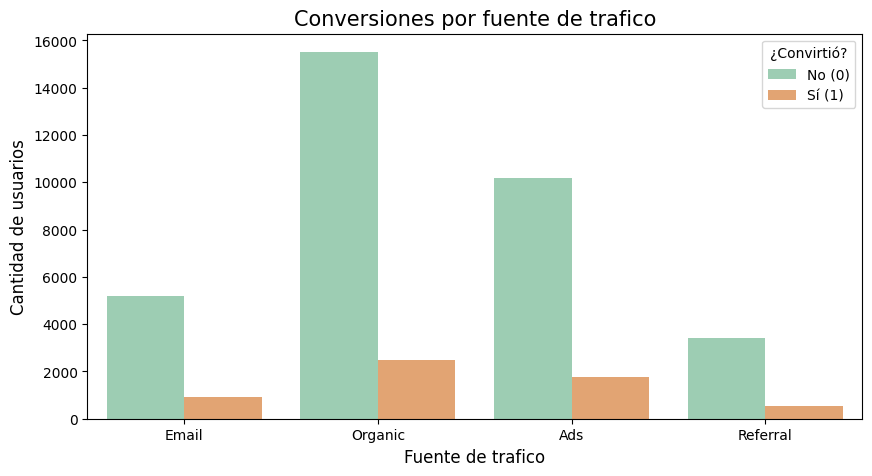

In [44]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='traffic_source', hue='converted',palette = ["#95D5B2", "#F4A261"])
plt.title('Conversiones por fuente de trafico', fontsize=15)
plt.xlabel('Fuente de trafico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()


In [45]:
tabla = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
tabla

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


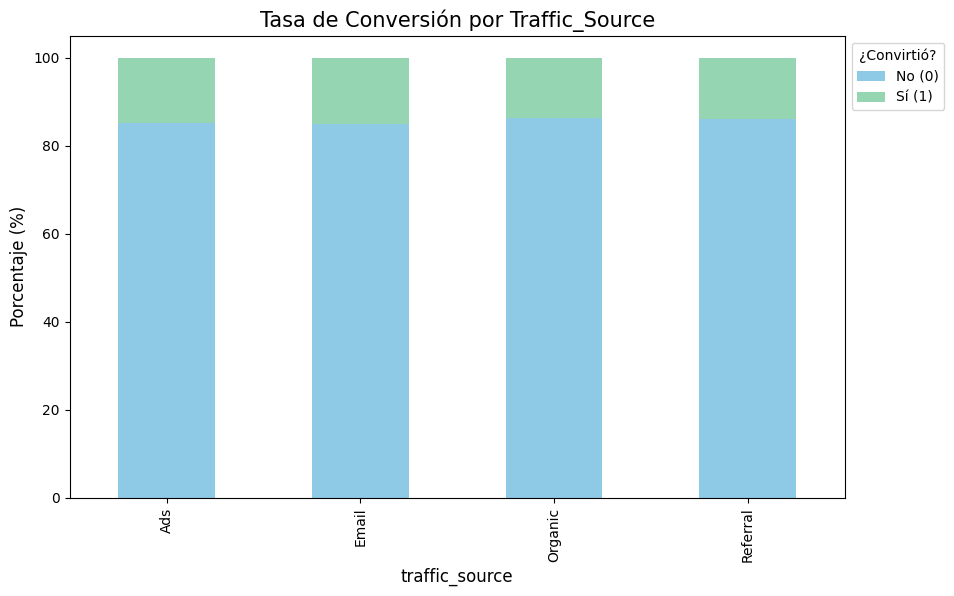

In [46]:
tabla.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por Traffic_Source', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('traffic_source', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [47]:
print("Se observa una tasa marginal 1,20 puntos porcentuales (13.78% - 14.99%)  al momento de comparar la conversion por tipo de fuente de trafico, por ende yo recomiendo una analisis adicional atraves de una segmentacion por edad.")

Se observa una tasa marginal 1,20 puntos porcentuales (13.78% - 14.99%)  al momento de comparar la conversion por tipo de fuente de trafico, por ende yo recomiendo una analisis adicional atraves de una segmentacion por edad.


### Relación entre el tipo de usuario y la conversión

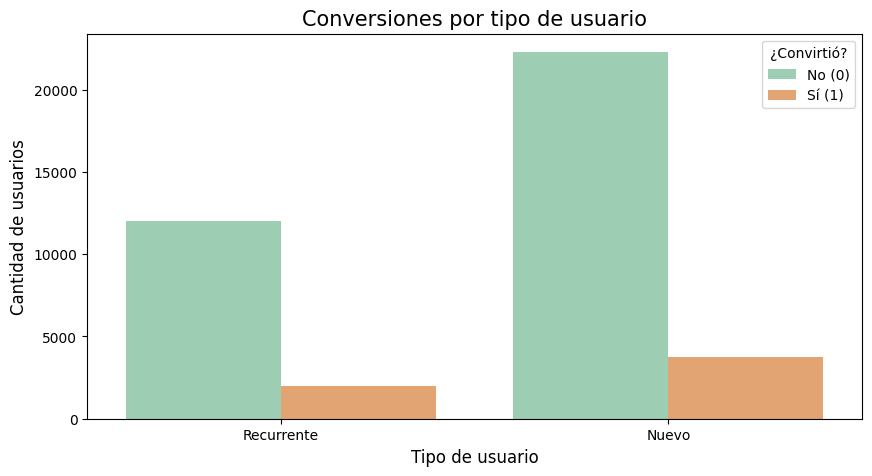

In [48]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='user_type', hue='converted',palette = ["#95D5B2", "#F4A261"])
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()


In [49]:
tabla = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
tabla

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


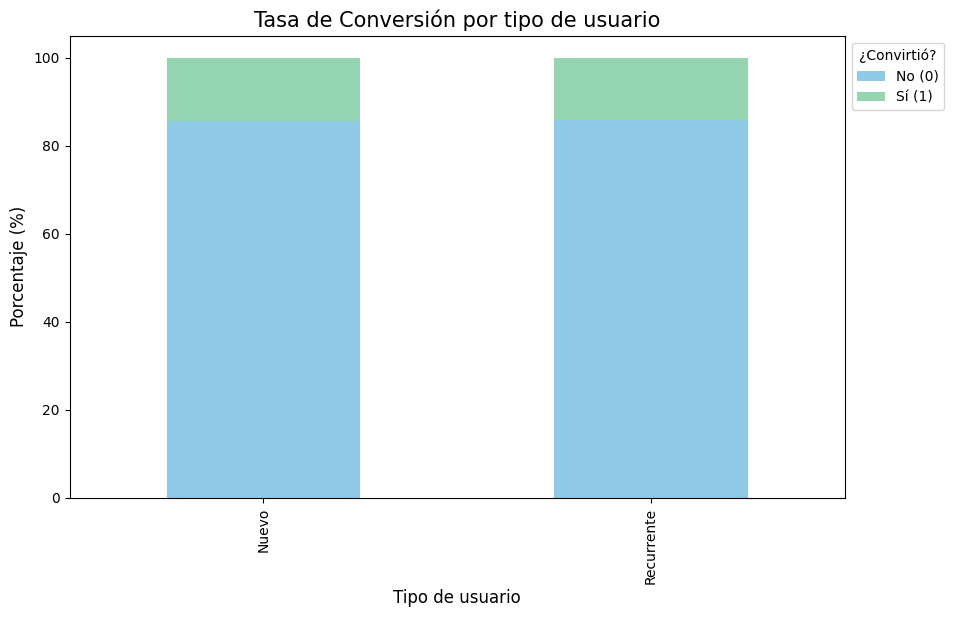

In [50]:
tabla.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])

plt.title('Tasa de Conversión por tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


In [51]:
print("Se observa una tasa marginal 0,26 puntos porcentuales (14.35% - 14.09%)  al momento de comparar la conversion por tipo de usuario, por ende yo recomiendo una analisis adicional atraves de una segmentacion por edad.")

Se observa una tasa marginal 0,26 puntos porcentuales (14.35% - 14.09%)  al momento de comparar la conversion por tipo de usuario, por ende yo recomiendo una analisis adicional atraves de una segmentacion por edad.


## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

  Gasto promedio por usuario que convirtió:
- Observacion 1 pagina B (68) genera mayor gasto promedio que la pagina A (61)
- Observacion 2 se rechaza la hipotesis inicial (H0) ya que los promedios de las 2 paginas no son iguales.
 
  Interpretación:  El resultado nos dice que la probabilidad de que sea "suerte" es muy baja, entonces tenemos una diferencia estadísticamente significativa. Rechazamos la hipótesis nula de igualdad y concluimos que las páginas no se comportan igual.
  
  

#### **Tasa de conversión:** 
- Observacion 1 la pagina B tiene una tasa de conversion (15,95) mayor que la pagina A (12,57)
- Observacion 2 se rechaza la hipotesis inicial (H0), ya que las tasa de conversion de las 2 paginas no son iguales
- **Interpretación:**
Con base en en una prueba z para proporciones, encontramos evidencia estadística de una diferencia en la tasa de conversión entre las páginas A y B de 3.38 puntos porcentuales. En particular, la página B muestra una tasa de conversión mayor que la página A. Este resultado se basa en una muestra de usuarios y no evalúa si la magnitud de la diferencia es suficiente para justificar una decisión de negocio.
  **Recomendacion para el negocio**
---Se sugiere un analisis adicional por segmentacion por region para buscar si hay algun patron que puede explicar esta diferencia de tasa de conversion entre las 2 paginas.

#### 📊 **Segmentación por fuente de tráfico**
- Observacion: hay una tasa marginal 1,20 puntos porcentuales 13.78% Organic - 14.99% Email.
- **Interpretación:**
 Se observa una tasa marginal 1,20 puntos porcentuales (13.78% - 14.99%)  al momento de comparar la conversion por tipo de fuente de trafico, por ende yo recomiendo una analisis adicional atraves de una segmentacion por edad.
 ---

#### 📊 **Segmentación por tipo de usuario**
- Observacion tasa marginal 0,26 puntos porcentuales 14.35% nuevo - 14.09% recurrente  
- **Interpretación:**
Se observa una tasa marginal 0,26 puntos porcentuales (14.35% - 14.09%)  al momento de comparar la conversion por tipo de usuario, por ende yo recomiendo una analisis adicional atraves de una segmentacion por edad.


Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Recomendación 1: Se recomienda investigar qué elementos de la página B (diseño, flujo de compra, productos destacados) contribuyen a este mayor gasto, para evaluar si pueden aplicarse a la página A."
-  Recomendación 2: con respecto a la tasa de conversion se sugiere analisis adicional via segmentacion por region para buscar si hay algun patron que puede explicar esta diferencia de tasa de conversion entre las 2 paginas
-  Recomendacion 3: con respecto a la segmentacion por tipo de usuario y fuente de trafico se sugiere analisis adicional atraves de una segmentacion por edad.